## Clustering

# ML - Aprendizaje No Supervisado

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)  

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 11
Coordenadas de los centroides:
[[ 5.70417769  0.20080413]
 [ 8.01619897  7.99353962]
 [ 8.66251892  4.17937554]
 [-0.05395305 -9.43649174]
 [ 2.7068665  -8.30320036]
 [ 7.69174101 -3.73770588]
 [-9.19350935 -5.05870458]
 [-7.63677409  1.40555761]
 [-2.15073423  4.12558064]
 [ 6.53582625  2.79397907]
 [-6.23245182  3.88982811]]


In [103]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

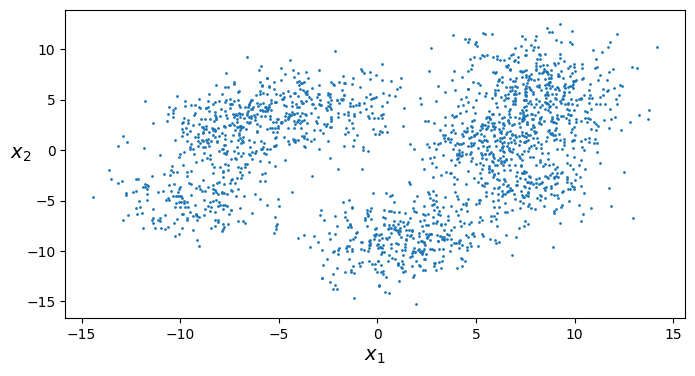

In [104]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [105]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred    

array([4, 3, 0, ..., 8, 4, 5], shape=(2000,), dtype=int32)

In [106]:
kmeans.cluster_centers_

array([[ 0.1631631 , -9.6517583 ],
       [ 3.53619196, -7.19846921],
       [-9.42939082, -5.19577995],
       [ 7.81671088,  7.84269451],
       [-5.146321  ,  4.72270103],
       [ 7.92387822, -3.40791333],
       [ 5.36316817,  0.93840143],
       [-8.66279719,  2.44171518],
       [ 9.18516322,  3.49555265],
       [-6.12825898, -0.35953416],
       [-1.05678878,  4.33527272]])

In [107]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([10,  6, 10, 10], dtype=int32)

In [108]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

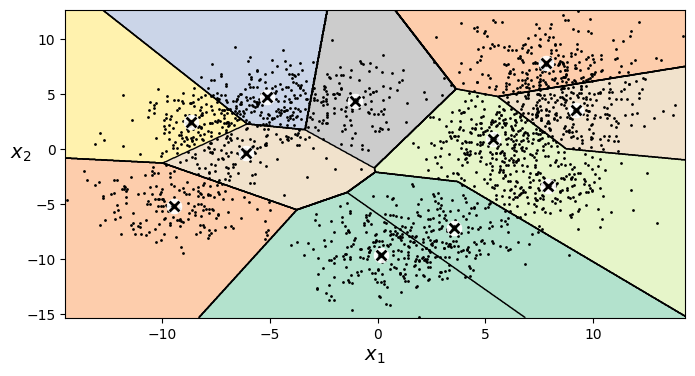

In [109]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [110]:
kmeans.transform(X_new)

array([[11.65290066,  9.85476988, 11.86139369,  9.75899832,  5.82217491,
         9.59340256,  5.46722639,  8.67405138,  9.3061217 ,  6.56680741,
         2.56325988],
       [11.99212721,  9.21408366, 14.36206827,  7.57217161,  8.5892751 ,
         7.31369286,  2.59066697, 11.67115892,  6.36340489,  9.42828264,
         4.68092234],
       [13.04118817, 12.11323985, 10.41671134, 11.85128366,  2.75216145,
        12.66461482,  8.61352254,  5.69025078, 12.19523576,  4.59047645,
         2.35775806],
       [12.55670461, 11.69538842, 10.02806538, 12.0642289 ,  3.08983716,
        12.41912055,  8.5077125 ,  5.66309713, 12.22576492,  4.23827086,
         2.67288155]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.



In [111]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=11, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=11, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=11, n_init=1, random_state=5)


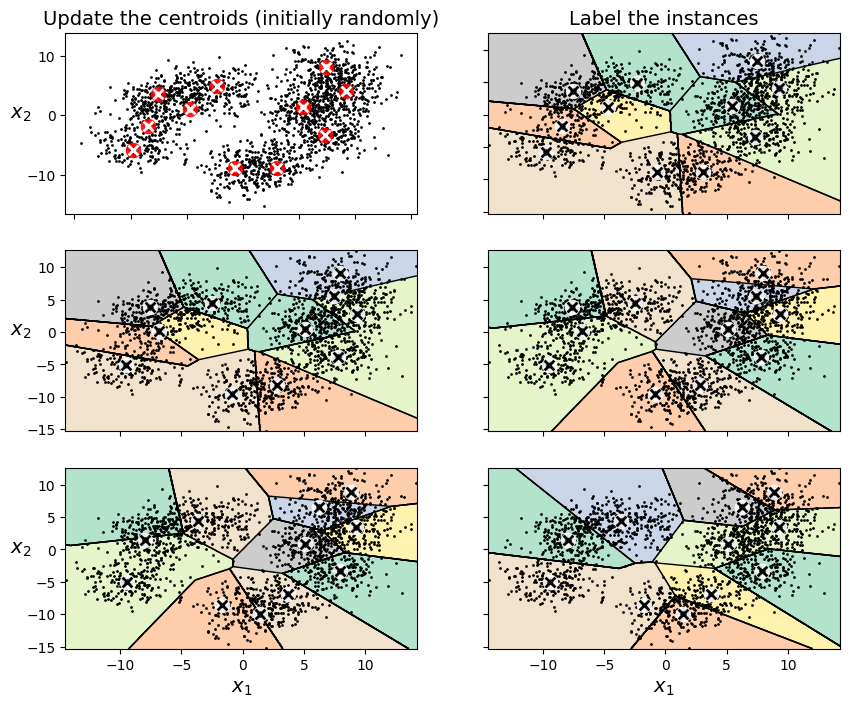

In [112]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [113]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

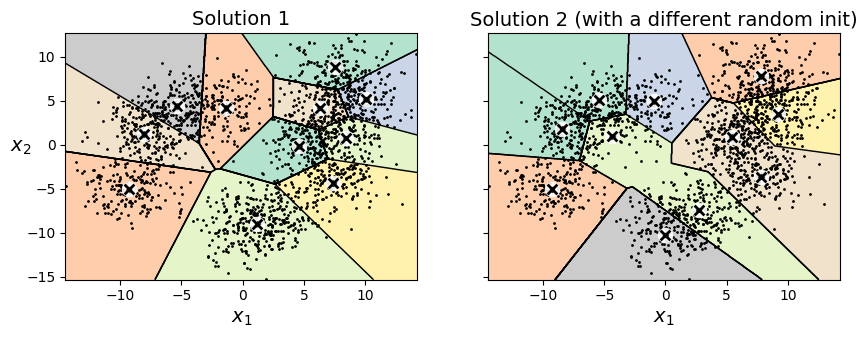

In [114]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.

In [115]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=11, n_init=10,
       random_state=11)


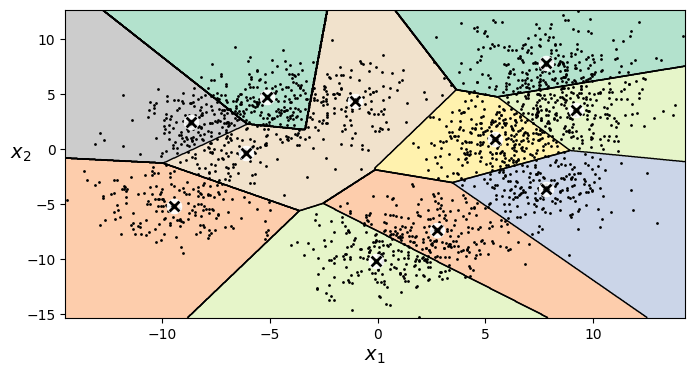

In [116]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto, que optimiza el cálculo de distancias) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria. A continuación veremos cómo funciona este último usando el dataset MNIST, empleando el objeto [MiniBatchKMeans]

In [117]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [118]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [119]:
best_kmeans.score(X)

-21444.1238403155

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.



### Encontrando el número óptimo de grupos

In [120]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.35944059194805894

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

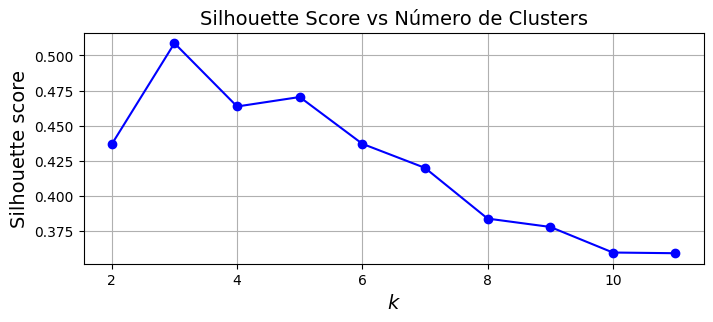

In [121]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers)) 
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

### ELBOW METHOD 

Calcula la inercia para distintos valores de k

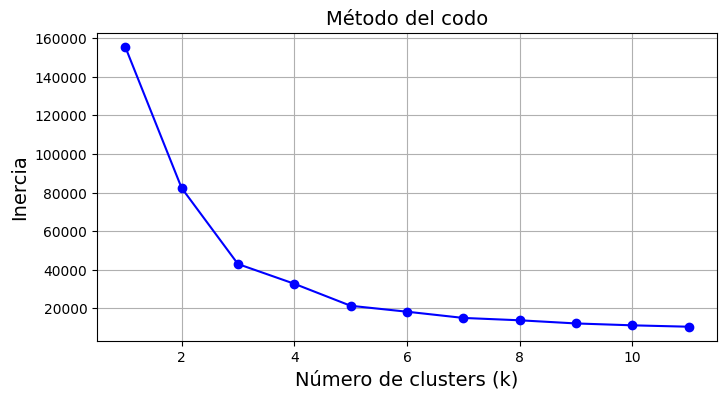

In [122]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()


También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

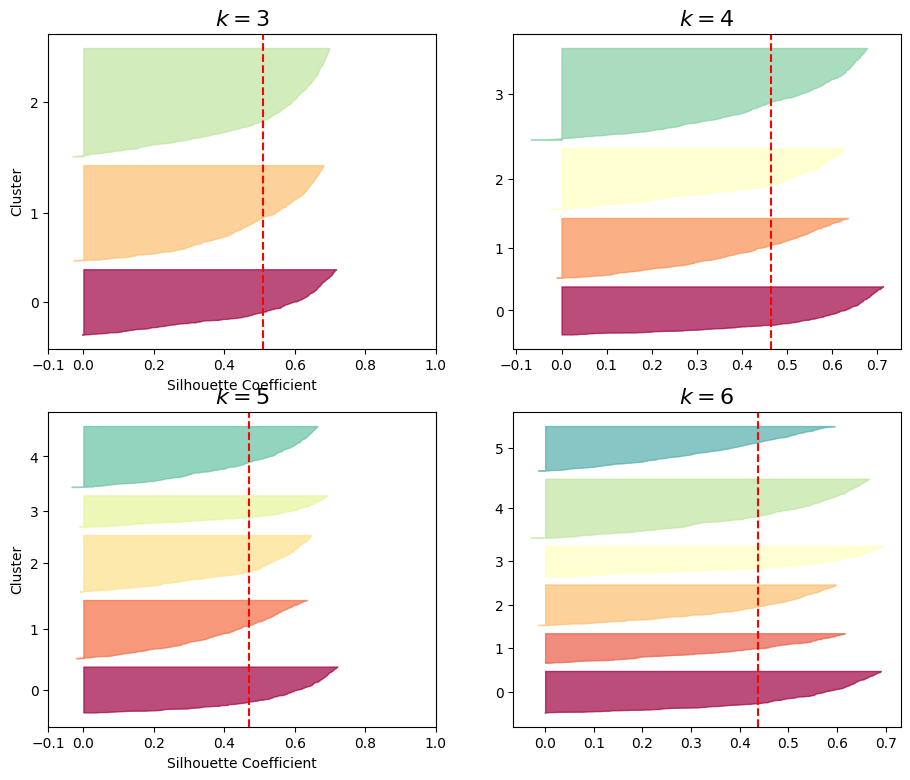

In [123]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

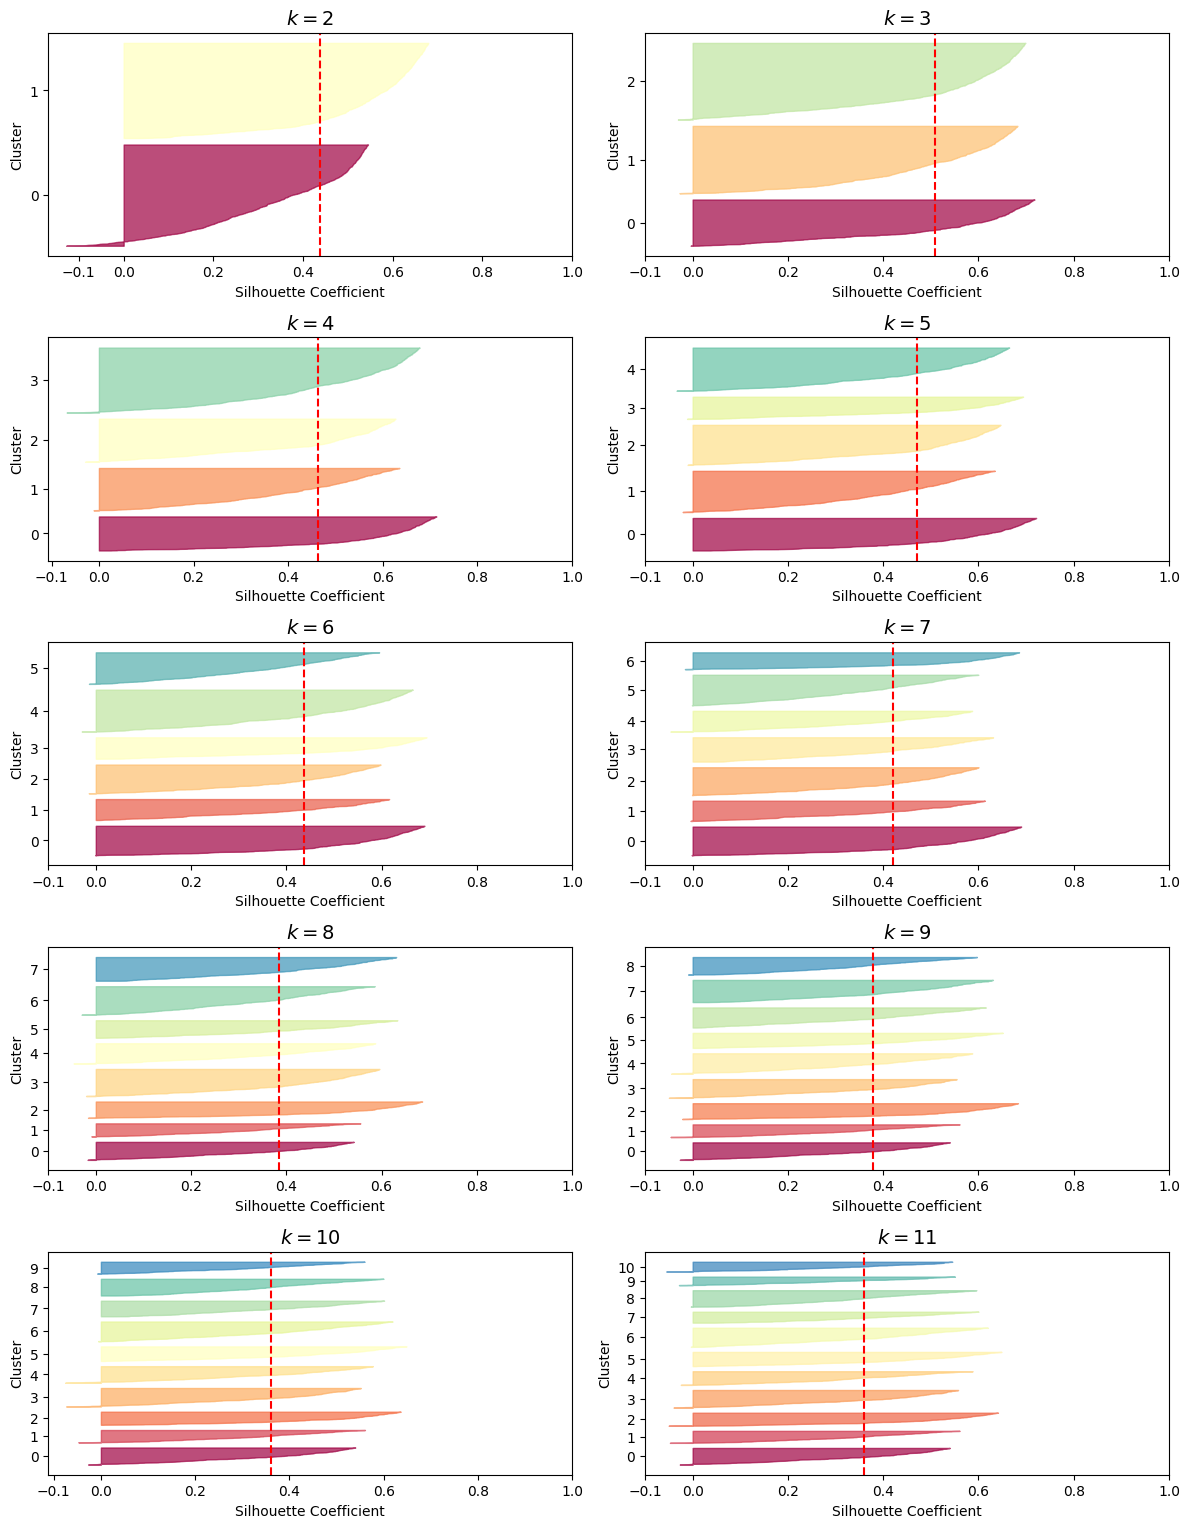

In [124]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()


### K-Means para aprendizaje semi-supervisado.

En esta sección se adapta el aprendizaje semi-supervisado al dataset de imágenes LEGO.

El dataset que estás usando tiene las imágenes directamente dentro de la carpeta `dataset`, no separadas por carpetas de clase. Por eso la etiqueta se extrae desde el nombre del archivo.

Ejemplo:

`2357 brick corner 1x2x2 000R.png` → clase `2357`

Luego las imágenes se convierten a números, se normalizan, se aplanan y se usan con K-Means y Regresión Logística.


In [125]:
import os
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Ruta del dataset
BASE_PATH = r"C:\\Users\\juant\\Downloads\\machine learning-20260330T151333Z-1-001\\machine learning\\lab7\\legomnist\\dataset"

IMG_SIZE = (64, 64)

X_list = []
y_list = []

# Verificar que la ruta exista
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(f"No existe la ruta: {BASE_PATH}")

# Recorrer todos los archivos de la carpeta dataset
for archivo in os.listdir(BASE_PATH):

    # Aceptar imágenes png, jpg y jpeg
    if not archivo.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    img_path = os.path.join(BASE_PATH, archivo)

    try:
        # Abrir imagen en RGB
        img = Image.open(img_path).convert('RGB')

        # Redimensionar a 28x28
        img = img.resize(IMG_SIZE)

        # Convertir imagen a arreglo numérico y normalizar entre 0 y 1
        img_array = np.array(img, dtype=np.float32) / 255.0

        # Guardar imagen procesada
        X_list.append(img_array)

        # Extraer la clase desde el primer valor del nombre del archivo
        # Ejemplo: "2357 brick corner 1x2x2 000R.png" -> "2357"
        clase = archivo.split()[0]
        y_list.append(clase)

    except Exception as e:
        print(f"No se pudo cargar {archivo}: {e}")

# Verificar que sí se hayan cargado imágenes
if len(X_list) == 0:
    raise ValueError("No se cargó ninguna imagen. Revisa la ruta y la extensión de los archivos.")

# Convertir listas a arreglos numpy
X_full = np.array(X_list)                  
X_flat = X_full.reshape(len(X_full), -1)  

# Convertir etiquetas de texto a números
le = LabelEncoder()
y_full = le.fit_transform(y_list)

print(f'Total imágenes     : {len(X_flat)}')
print(f'Shape original     : {X_full.shape}')
print(f'Shape aplanado     : {X_flat.shape}')
print(f'Clases encontradas : {len(le.classes_)}')
print(f'Algunas clases     : {list(le.classes_)[:10]}')


Total imágenes     : 40000
Shape original     : (40000, 64, 64, 3)
Shape aplanado     : (40000, 12288)
Clases encontradas : 50
Algunas clases     : [np.str_('14719'), np.str_('15672'), np.str_('18654'), np.str_('2357'), np.str_('2420'), np.str_('2780'), np.str_('27925'), np.str_('3001'), np.str_('3002'), np.str_('3003')]


Train / Test split

Igual que en el cuadernillo original separamos un conjunto de test que **nunca** tocamos durante el entrenamiento.

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_full, test_size=0.15, stratify=y_full, random_state=42
)

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

Train : (34000, 12288)
Test  : (6000, 12288)


K-Means: encontrar imágenes representativas

Como tienes aproximadamente 50 clases reales, se puede usar `k = 100` para obtener más representantes que clases. Esto ayuda porque un mismo tipo de pieza puede aparecer con pequeñas variaciones, rotaciones o condiciones visuales distintas.


In [127]:
from sklearn.cluster import KMeans

k = 100
kmeans = KMeans(n_clusters=k, random_state=42)

# fit_transform devuelve la distancia de cada imagen a cada centroide
# Forma esperada: (n_train, k)
X_lego_dist = kmeans.fit_transform(X_train)

print(f'Número de clusters: {k}')
print(f'Shape distancias  : {X_lego_dist.shape}')
print('(filas=imagenes, columnas=centroides)')


Número de clusters: 100
Shape distancias  : (34000, 100)
(filas=imagenes, columnas=centroides)


In [128]:
# Imagen mas cercana a cada centroide -> representante del grupo
idxs = np.argmin(X_lego_dist, axis=0)   # indice de la img mas cercana por grupo
X_representative = X_train[idxs]       

print(f'Representantes encontrados: {X_representative.shape}')

Representantes encontrados: (100, 12288)


Visualizar los representantes

En la práctica real tendrías que etiquetar estas imágenes a mano. usamos `y_train` directamente.

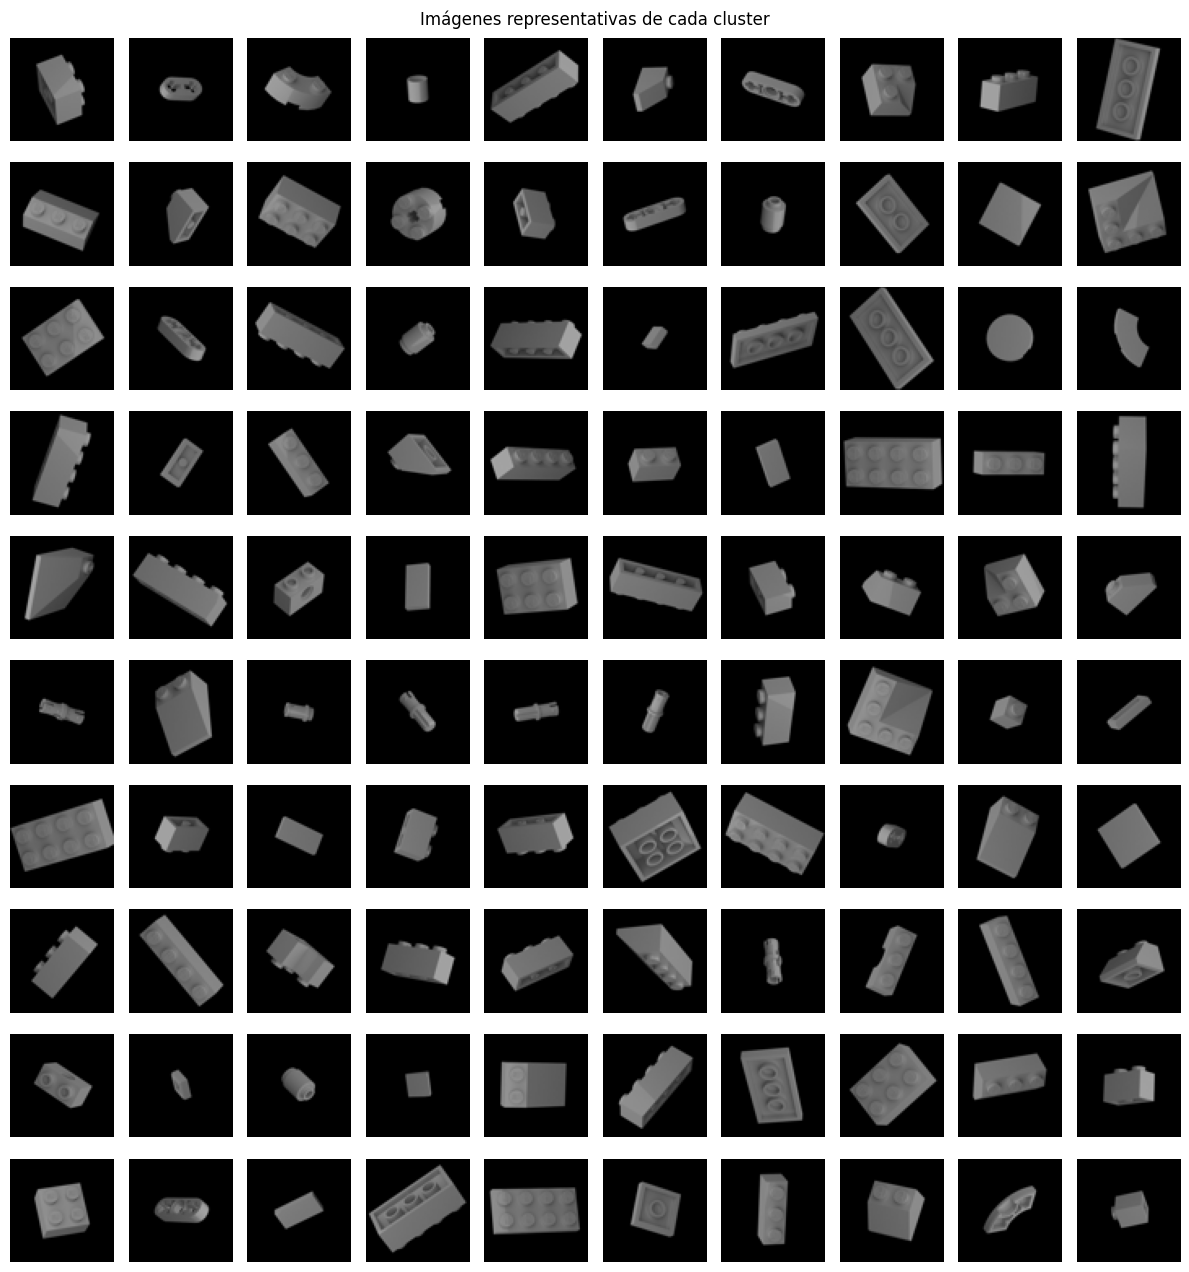

In [129]:
import math

cols = 10
rows = math.ceil(len(X_representative) / cols)

plt.figure(figsize=(12, rows * 1.3))
for index, img in enumerate(X_representative[:100]):
    plt.subplot(rows, cols, index + 1)
    plt.imshow(img.reshape(64, 64, 3))
    plt.axis('off')

plt.suptitle('Imágenes representativas de cada cluster', fontsize=12)
plt.tight_layout()
plt.show()


In [130]:
# Etiquetado manual: en la practica lo harias mirando las imagenes
# Aqui usamos y_train[idxs] como trampa
y_representative = y_train[idxs]
print('Etiquetas de los representantes:')
print(y_representative)
print('Clases:', [le.classes_[i] for i in y_representative])

Etiquetas de los representantes:
[ 9 38 25  2 12 21 47 23 31 13 19 21  8 46 10 47 24 14 26 49 14 47 12 24
 12 28 13 13 37  6 12 36 31 20 12 10 27  7 31  7 34 12 35 27  8 12 10 20
 23 21  5 29 40 42 42 42 31 49 11 27  7 10 27 10 31 49  7 38 29 26 31 12
  3 31 31 18  5 44 12 20 35 28 24 45 29 12 13  8 19 10  9 47 27 18 13 15
 31 20  6 11]
Clases: [np.str_('3003'), np.str_('41677'), np.str_('3063'), np.str_('18654'), np.str_('3010'), np.str_('3040'), np.str_('6632'), np.str_('3046'), np.str_('3622'), np.str_('3020'), np.str_('3038'), np.str_('3040'), np.str_('3002'), np.str_('6143'), np.str_('3004'), np.str_('6632'), np.str_('3062'), np.str_('3021'), np.str_('3068'), np.str_('99301'), np.str_('3021'), np.str_('6632'), np.str_('3010'), np.str_('3062'), np.str_('3010'), np.str_('3070'), np.str_('3020'), np.str_('3020'), np.str_('4150'), np.str_('27925'), np.str_('3010'), np.str_('3794'), np.str_('3622'), np.str_('3039'), np.str_('3010'), np.str_('3004'), np.str_('3069'), np.str_('3001'), np

In [131]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative, y_representative)

score = log_reg2.score(X_test, y_test)
print(f'Accuracy con {k} representantes: {score:.4f} ({score*100:.1f}%)')


CPU times: total: 17.2 s
Wall time: 13 s
Accuracy con 100 representantes: 0.1523 (15.2%)


Representantes vs imágenes aleatorias

Se compara el modelo entrenado con imágenes representativas seleccionadas por K-Means contra otro modelo entrenado con la misma cantidad de imágenes elegidas al azar.


In [132]:
idxs_random = np.random.choice(len(X_train), k, replace=False)

log_reg_random = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
%time log_reg_random.fit(X_train[idxs_random], y_train[idxs_random])

score_random = log_reg_random.score(X_test, y_test)

print(f'Accuracy con {k} imágenes ALEATORIAS      : {score_random:.4f} ({score_random*100:.1f}%)')
print(f'Accuracy con {k} imágenes REPRESENTANTES  : {score:.4f} ({score*100:.1f}%)')
print(f'Mejora usando representantes              : +{(score - score_random)*100:.1f}%')


CPU times: total: 9.83 s
Wall time: 7.29 s
Accuracy con 100 imágenes ALEATORIAS      : 0.1132 (11.3%)
Accuracy con 100 imágenes REPRESENTANTES  : 0.1523 (15.2%)
Mejora usando representantes              : +3.9%


Propagación de etiquetas

Una vez que tenemos el representante etiquetado de cada cluster, asignamos **esa misma etiqueta**
a todas las imágenes del cluster. Así etiquetamos todo el dataset automáticamente.

In [133]:
# Propagar: cada imagen recibe la etiqueta de su representante de cluster
y_train_propagated = np.empty(len(X_train), dtype=int)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative[i]

print(f'Etiquetas propagadas a {len(y_train_propagated)} imagenes')

Etiquetas propagadas a 34000 imagenes


In [134]:
# Entrenar con etiquetas propagadas
# Para que sea más rápido, usamos una muestra de 1000 imágenes.
n_train_small = 1000

log_reg3 = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:n_train_small], y_train_propagated[:n_train_small])

score3 = log_reg3.score(X_test, y_test)
print(f'Accuracy con etiquetas propagadas: {score3:.4f} ({score3*100:.1f}%)')


CPU times: total: 1min 34s
Wall time: 36.8 s
Accuracy con etiquetas propagadas: 0.1453 (14.5%)


### Aprendizaje Activo

El modelo puede equivocarse al propagar etiquetas. El **aprendizaje activo** busca las imágenes
donde el modelo tiene menos confianza y las corrige manualmente. Igual que en el cuadernillo.

In [135]:
# Encontrar imágenes con menor confianza
# El modelo predice probabilidades y revisamos dónde está más inseguro.
probas = log_reg3.predict_proba(X_train[:n_train_small])
labels_ixs = np.argmax(probas, axis=1)
confianza = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

# Ordenar de menor a mayor confianza
sorted_ixs = np.argsort(confianza)

print(f'Confianza de las 10 imágenes más dudosas: {confianza[sorted_ixs[:10]].round(3)}')


Confianza de las 10 imágenes más dudosas: [0.53  0.583 0.596 0.644 0.647 0.654 0.693 0.705 0.711 0.72 ]


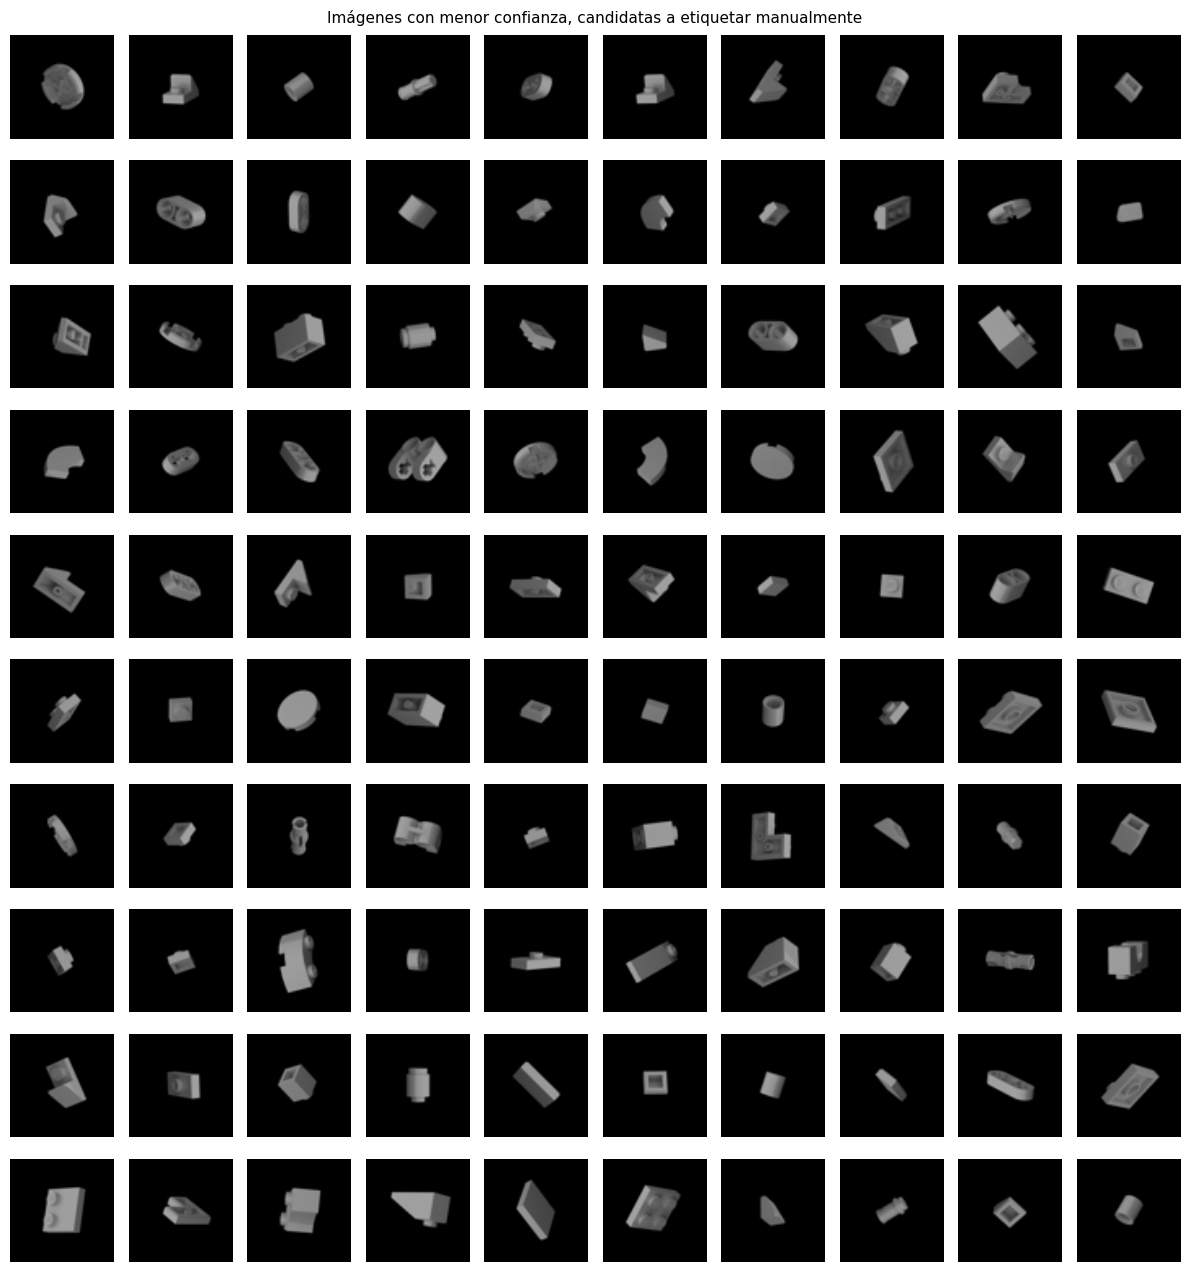

In [137]:
# Visualizar las imágenes más dudosas
X_lowest = X_train[:n_train_small][sorted_ixs[:k]]

cols = 10
rows = math.ceil(len(X_lowest) / cols)

plt.figure(figsize=(12, rows * 1.3))
for index, img in enumerate(X_lowest):
    plt.subplot(rows, cols, index + 1)
    plt.imshow(img.reshape(64, 64, 3), interpolation='bilinear')
    plt.axis('off')

plt.suptitle('Imágenes con menor confianza, candidatas a etiquetar manualmente', fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# En un caso real, estas etiquetas se corregirían manualmente.
# Aquí usamos y_train como si fuera la corrección hecha por el usuario.
y_lowest = y_train[:n_train_small][sorted_ixs[:k]]

print('Etiquetas reales de las imágenes más dudosas:')
print(y_lowest)


Etiquetas reales de las imágenes más dudosas:
[43 35 27 21  1 32  1 39 39 32 36 36  1 11 10 16  3 38 11 41 45 21 25 35
 43 15 35  1 38 45 22 27 26  1  5 27 48  2 45  9 27  2 46  1 26 32 46 24
 48 37  6 17 28 20 38 33 46 23  1  5 35 11 37 38 37 48  6 47 43 16 35  6
 17 27  0 47 48  9 39  1]


In [ ]:
# Combinar etiquetas propagadas con corrección activa
y_train2 = y_train_propagated[:n_train_small].copy()
y_train2[sorted_ixs[:k]] = y_lowest


In [ ]:
# Entrenar modelo final
log_reg5 = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:n_train_small], y_train2)

score5 = log_reg5.score(X_test, y_test)
print(f'Accuracy final con propagación + aprendizaje activo: {score5:.4f} ({score5*100:.1f}%)')


CPU times: total: 13.7 s
Wall time: 5.73 s
Accuracy final con propagación + aprendizaje activo: 0.1255 (12.6%)


### Resumen comparativo

In [ ]:
print('='*60)
print('RESUMEN — Accuracy en test set')
print('='*60)
print(f'{k} imágenes aleatorias              : {score_random*100:.1f}%')
print(f'{k} representantes con K-Means       : {score*100:.1f}%')
print(f'Propagación de etiquetas             : {score3*100:.1f}%')
print(f'Propagación + Aprendizaje Activo     : {score5*100:.1f}%')
print('='*60)


RESUMEN — Accuracy en test set
80 imágenes aleatorias              : 10.8%
80 representantes con K-Means       : 12.4%
Propagación de etiquetas             : 11.6%
Propagación + Aprendizaje Activo     : 12.6%
